<a href="https://colab.research.google.com/github/lizbethsalsavilca-cmd/Optimizacion-logistica-maritima./blob/main/Optimizacion_logistica_maritima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Optimización del transporte marítimo de contenedores de exportación**

# 1. Problemática del caso.


Andes Pacific Shipping programa su plan semanal de exportación de contenedores refrigerados y secos hacia dos mercados estratégicos: Los Ángeles y Shanghái. Para ello, cuenta con un volumen total de 1,400 contenedores comprometidos comercialmente. El despacho se realiza desde 4 puertos peruanos de salida: Callao, Paita, Matarani y Chancay. El objetivo es determinar la cantidad óptima de contenedores a enviar a través de cada una de las 8 rutas marítimas posibles para minimizar el costo logístico semanal total , respetando las capacidades de despacho de los puertos , los cupos máximos contratados por ruta , el presupuesto financiero máximo de US$ 2,250,000 y las exigencias de tiempos máximos permitidos por servicio al cliente.

# 2. Datos y parámetros

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


# 3. Variables de decisión

Se definen 8 variables de decisión con doble subíndice "x_ij", donde:

- **i** = puerto de origen (1: Callao, 2: Paita, 3: Matarani, 4: Chancay)
- **j** = destino (1: Los Ángeles, 2: Shanghái)

| Variable | Puerto origen | Destino | Significado |
|----------|---------------|---------|-------------|
| x₁₁ | Callao (i=1) | Los Ángeles (j=1) | Contenedores vía Callao → Los Ángeles |
| x₁₂ | Callao (i=1) | Shanghái (j=2) | Contenedores vía Callao → Shanghái |
| x₂₁ | Paita (i=2) | Los Ángeles (j=1) | Contenedores vía Paita → Los Ángeles |
| x₂₂ | Paita (i=2) | Shanghái (j=2) | Contenedores vía Paita → Shanghái |
| x₃₁ | Matarani (i=3) | Los Ángeles (j=1) | Contenedores vía Matarani → Los Ángeles |
| x₃₂ | Matarani (i=3) | Shanghái (j=2) | Contenedores vía Matarani → Shanghái |
| x₄₁ | Chancay (i=4) | Los Ángeles (j=1) | Contenedores vía Chancay → Los Ángeles |
| x₄₂ | Chancay (i=4) | Shanghái (j=2) | Contenedores vía Chancay → Shanghái |

**Condición de no negatividad:**  
x_ij ≥ 0 para todas las variables (no se admiten cantidades negativas).

**En el código, el orden de las variables:**  
`[x₁₁, x₁₂, x₂₁, x₂₂, x₃₁, x₃₂, x₄₁, x₄₂]`

# 4. Función Objetivo

In [30]:
# Minimizar el costo logístico total semanal (en USD)
# Orden de las variables: [x11, x12, x21, x22, x31, x32, x41, x42]

c = [1250, 1800, 1340, 1920, 1420, 2050, 1180, 1720]

print("Vector de costos (c):")
print(f"  x11 (Callao→LA):    ${c[0]:,}")
print(f"  x12 (Callao→SHA):   ${c[1]:,}")
print(f"  x21 (Paita→LA):     ${c[2]:,}")
print(f"  x22 (Paita→SHA):    ${c[3]:,}")
print(f"  x31 (Matarani→LA):  ${c[4]:,}")
print(f"  x32 (Matarani→SHA): ${c[5]:,}")
print(f"  x41 (Chancay→LA):   ${c[6]:,}")
print(f"  x42 (Chancay→SHA):  ${c[7]:,}")

Vector de costos (c):
  x11 (Callao→LA):    $1,250
  x12 (Callao→SHA):   $1,800
  x21 (Paita→LA):     $1,340
  x22 (Paita→SHA):    $1,920
  x31 (Matarani→LA):  $1,420
  x32 (Matarani→SHA): $2,050
  x41 (Chancay→LA):   $1,180
  x42 (Chancay→SHA):  $1,720


# 5. Restricciones

In [31]:
# Matriz A_ub (17 restricciones de desigualdad) y vector b_ub

A_ub = [
    # R1 Capacidad de puertos (4 restricciones)
    [1, 1, 0, 0, 0, 0, 0, 0],   # Callao ≤ 520
    [0, 0, 1, 1, 0, 0, 0, 0],   # Paita ≤ 280
    [0, 0, 0, 0, 1, 1, 0, 0],   # Matarani ≤ 240
    [0, 0, 0, 0, 0, 0, 1, 1],   # Chancay ≤ 460

    # R3 Cupos máximos por ruta (8 restricciones)
    [1, 0, 0, 0, 0, 0, 0, 0],   # x11 ≤ 300
    [0, 1, 0, 0, 0, 0, 0, 0],   # x12 ≤ 330
    [0, 0, 1, 0, 0, 0, 0, 0],   # x21 ≤ 220
    [0, 0, 0, 1, 0, 0, 0, 0],   # x22 ≤ 180
    [0, 0, 0, 0, 1, 0, 0, 0],   # x31 ≤ 160
    [0, 0, 0, 0, 0, 1, 0, 0],   # x32 ≤ 140
    [0, 0, 0, 0, 0, 0, 1, 0],   # x41 ≤ 280
    [0, 0, 0, 0, 0, 0, 0, 1],   # x42 ≤ 360

    # R5 Concentración Chancay (1 restricción)
    [0, 0, 0, 0, 0, 0, 1, 1],   # x41 + x42 ≤ 490

    # R4 Uso estratégico Chancay (negada: x42 ≥ 252 → -x42 ≤ -252)
    [0, 0, 0, 0, 0, 0, 0, -1],  # -x42 ≤ -252

    # R6 Presupuesto (1 restricción)
    [1250, 1800, 1340, 1920, 1420, 2050, 1180, 1720],  # ≤ 2,250,000

    # R7a Tiempo promedio a Los Ángeles (1 restricción)
    [15, 0, 16, 0, 18, 0, 14, 0],  # ≤ 10,540

    # R7b Tiempo promedio a Shanghái (1 restricción)
    [0, 28, 0, 30, 0, 32, 0, 27],  # ≤ 20,880
]

b_ub = [
    # Capacidades
    520, 280, 240, 460,
    # Cupos
    300, 330, 220, 180, 160, 140, 280, 360,
    # Concentración Chancay
    490,
    # Uso estratégico Chancay (negado)
    -252,
    # Presupuesto
    2250000,
    # Tiempos
    10540, 20880
]

# Matriz A_eq (2 restricciones de igualdad) y vector b_eq
A_eq = [
    [1, 0, 1, 0, 1, 0, 1, 0],   # Demanda Los Ángeles = 680
    [0, 1, 0, 1, 0, 1, 0, 1],   # Demanda Shanghái = 720
]

b_eq = [680, 720]

# Límites de variables (no negatividad)
bounds = [(0, None)] * 8

print("Matrices de restricciones definidas correctamente:")
print(f"A_ub: {len(A_ub)} restricciones × {len(A_ub[0])} variables")
print(f"b_ub: {len(b_ub)} valores")
print(f"A_eq: {len(A_eq)} restricciones × {len(A_eq[0])} variables")
print(f"b_eq: {len(b_eq)} valores")

Matrices de restricciones definidas correctamente:
A_ub: 17 restricciones × 8 variables
b_ub: 17 valores
A_eq: 2 restricciones × 8 variables
b_eq: 2 valores


# 6. Resolución con el solver

In [32]:
# Ejecución del solver matemático
res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

# Resultados de la plantilla
print(f"Estado: {res.message}")
print(f"Costo mínimo total: US$ {res.fun:,.2f}")
print(f"Flujos óptimos resultantes (x): {res.x}")

Estado: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Costo mínimo total: US$ 2,164,770.00
Flujos óptimos resultantes (x): [190. 330. 149. 131. 133.   7. 208. 252.]


In [33]:
# Definición de las etiquetas (Las Rutas)
rutas = [
    "Callao-LA",
    "Callao-SH",
    "Paita-LA",
    "Paita-SH",
    "Matarani-LA",
    "Matarani-SH",
    "Chancay-LA",
    "Chancay-SH"
]

solucion = pd.DataFrame({
    "Ruta": rutas,
    "Contenedores": res.x
})

solucion

,Ruta,Contenedores
0,Callao-LA,190.0
1,Callao-SH,330.0
2,Paita-LA,149.0
3,Paita-SH,131.0
4,Matarani-LA,133.0
5,Matarani-SH,7.0
6,Chancay-LA,208.0
7,Chancay-SH,252.0


REGIÓN FACTIBLE REDUCIDA

Como el problema tiene 8 variables, no puede graficarse completo. Lo siguiente es una representación reducida con las variables estratégicas de Chancay:

x41 = Chancay → Los Ángeles

x42 = Chancay → Shanghái

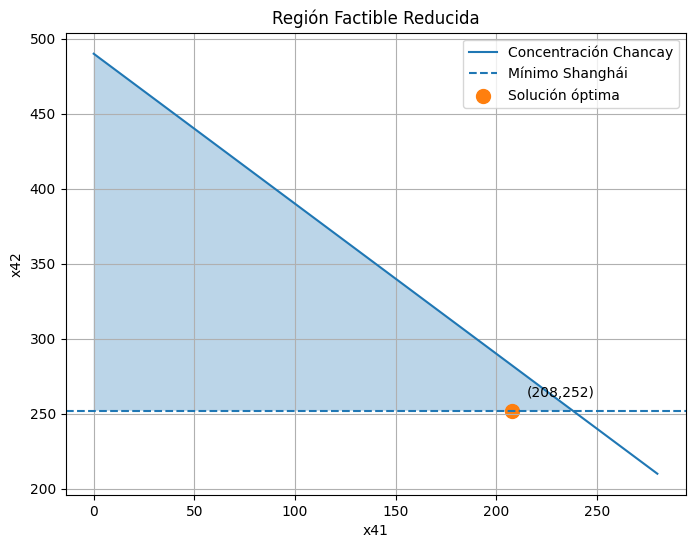

In [34]:
x41 = np.linspace(0, 280, 500)

limite_concentracion = 490 - x41

plt.figure(figsize=(8,6))

plt.plot(
    x41,
    limite_concentracion,
    label="Concentración Chancay"
)

plt.axhline(
    252,
    linestyle='--',
    label="Mínimo Shanghái"
)

plt.fill_between(
    x41,
    252,
    limite_concentracion,
    where=limite_concentracion >= 252,
    alpha=0.3
)

# Punto óptimo
plt.scatter(
    208,
    252,
    s=100,
    label="Solución óptima"
)

plt.annotate(
    "(208,252)",
    (208,252),
    textcoords="offset points",
    xytext=(10,10)
)

plt.xlabel("x41")
plt.ylabel("x42")
plt.title("Región Factible Reducida")
plt.legend()
plt.grid(True)
plt.show()

In [35]:

# TABLA EJECUTIVA DE RESULTADOS POR PUERTO


tabla_puerto = pd.DataFrame({

    "Puerto":[
        "Callao",
        "Paita",
        "Matarani",
        "Chancay"
    ],

    "Capacidad Despacho":[
        520,
        280,
        240,
        460
    ],

    "Capacidad Patio (TEU)":[
        780,
        420,
        360,
        700
    ],

    "Contenedores Utilizados":[
        res.x[0] + res.x[1],
        res.x[2] + res.x[3],
        res.x[4] + res.x[5],
        res.x[6] + res.x[7]
    ]

})

tabla_puerto["Utilización Puerto (%)"] = (
    tabla_puerto["Contenedores Utilizados"] /
    tabla_puerto["Capacidad Despacho"]
)*100

tabla_puerto["Capacidad Ociosa"] = (
    tabla_puerto["Capacidad Despacho"] -
    tabla_puerto["Contenedores Utilizados"]
)

tabla_puerto.round(2)


,Puerto,Capacidad Despacho,Capacidad Patio (TEU),Contenedores Utilizados,Utilización Puerto (%),Capacidad Ociosa
0,Callao,520,780,520.0,100.00,0.0
1,Paita,280,420,280.0,100.00,0.0
2,Matarani,240,360,140.0,58.33,100.0
3,Chancay,460,700,460.0,100.00,0.0


## Actividad 6: Visualizacion del plan óptimo##

,Los Ángeles,Shanghái
Puerto,,
Callao,190.0,330.0
Paita,149.0,131.0
Matarani,133.0,7.0
Chancay,208.0,252.0


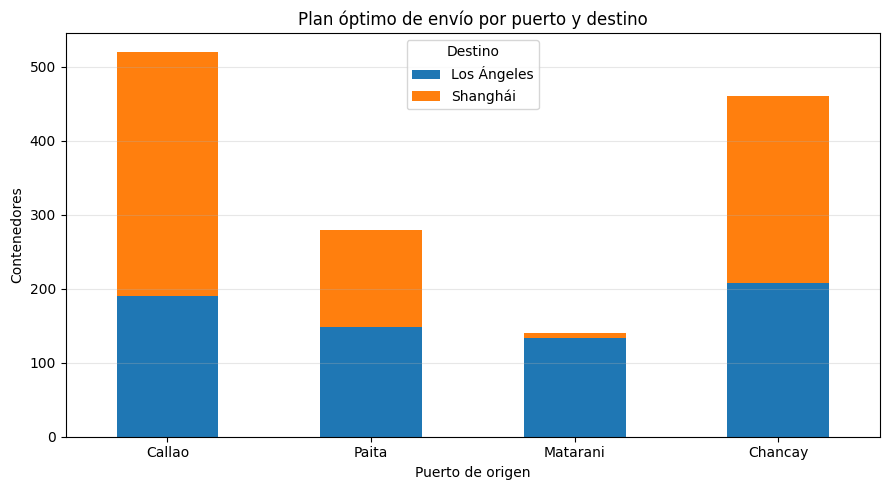

In [36]:
# Extraer variables de decisión óptimas
x11, x12, x21, x22, x31, x32, x41, x42 = res.x

# Crear tabla base por puerto y destino
plan_optimo = pd.DataFrame({
    "Puerto": ["Callao", "Paita", "Matarani", "Chancay"],
    "Los Ángeles": [x11, x21, x31, x41],
    "Shanghái": [x12, x22, x32, x42]
})

plan_optimo = plan_optimo.set_index("Puerto")

display(plan_optimo)

ax = plan_optimo.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5)
)

ax.set_title("Plan óptimo de envío por puerto y destino")
ax.set_xlabel("Puerto de origen")
ax.set_ylabel("Contenedores")
ax.legend(title="Destino")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tablas y gráficos


En esta sección se presentan gráficos y tablas adicionales que visualizan los resultados clave del modelo de optimización, ofreciendo una comprensión más intuitiva de la distribución de contenedores, la utilización de puertos y el impacto de los costos.

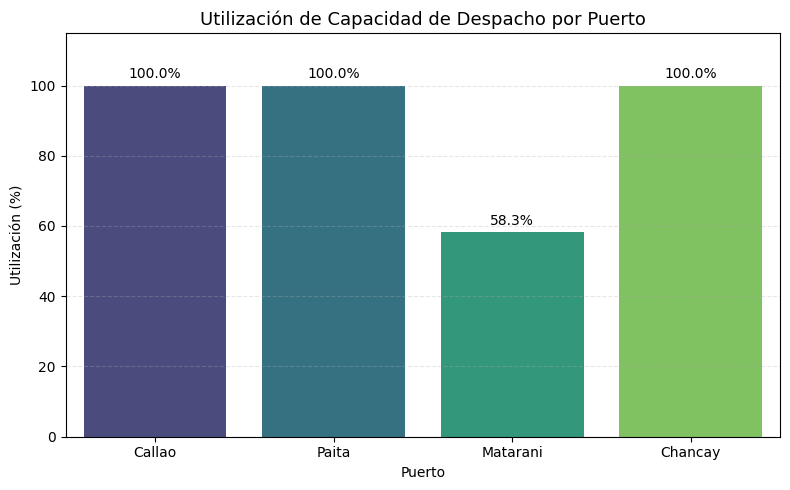

In [37]:
# Gráfico de Utilización de Puertos

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Puerto",
    y="Utilización Puerto (%)",
    data=tabla_puerto,
    hue="Puerto",          # evita el warning
    palette="viridis",
    legend=False
)

plt.title("Utilización de Capacidad de Despacho por Puerto", fontsize=13)
plt.xlabel("Puerto")
plt.ylabel("Utilización (%)")

plt.ylim(0, 115)

# Mostrar porcentaje sobre cada barra
for i, valor in enumerate(tabla_puerto["Utilización Puerto (%)"]):
    plt.text(
        i,
        valor + 2,
        f"{valor:.1f}%",
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones del Caso de Estudio de Optimización del Transporte Marítimo

1.  **Solución Óptima y Minimización de Costos:** El modelo de programación lineal ha identificado una solución óptima para el transporte de 1,400 contenedores, resultando en un costo logístico total mínimo de **US$ 2,164,770**. Esta solución es factible y cumple con todas las restricciones operativas, financieras y de servicio al cliente establecidas.

2.  **Utilización de Puertos y Restricciones Activas:**
    *   Los puertos de **Callao, Paita y Chancay** operan al **100% de su capacidad** de despacho, lo que los convierte en restricciones activas y puntos críticos en la cadena logística. Cualquier alteración en la capacidad de estos puertos afectaría directamente la factibilidad del plan.
    *   El puerto de **Matarani** presenta una utilización del **58.33%**, con una **holgura de 100 contenedores**. Esto lo posiciona como el único puerto con capacidad ociosa significativa, ofreciendo flexibilidad y un potencial de respaldo ante futuros incrementos de demanda o contingencias en otros puertos.

En síntesis, el modelo de programación lineal permitió diseñar una estrategia de transporte marítimo económicamente eficiente, alcanzando un costo mínimo de US$ 2,164,770 y cumpliendo todas las restricciones operativas, estratégicas y financieras planteadas. El análisis realizado permitió identificar puertos y rutas críticas para la operación. Los resultados obtenidos constituyen una herramienta valiosa para la toma de decisiones logísticas y la planificación estratégica del transporte internacional de contenedores.